<a href="https://colab.research.google.com/github/Laura-Filkova/CB2330-KICKASS-PROJECT/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project card

**The paper:**
Ginell, Emenecker, Lotthammer, Keeley, Plassmeyer, Razo, Usher, Pelham and Holehouse (2025). ***Sequence-based prediction of intermolecular interactions driven by disordered regions.*** *Science* 388, eadq8381. doi:10.1126/science.adq8381

**The data object:**
Supplementary Table S3 (`data/NIHMS2095256-supplement-Table_S3.xlsx`). Sheet S3A has 19,702 human intrinsically disordered regions (IDRs). Each row has the IDR sequence before phosphorylation (`sequence_pre`), the sequence after every experimentally reported phosphosite (S/T/Y) was replaced by glutamic acid (`sequence_post`), and the homotypic interaction parameter ε that FINCHES predicts for both (`epsilon_pre`, `epsilon_post`). Negative ε means the IDR attracts copies of itself, positive ε means it repels them. Sheet S3B is the same calculation with a second force field. In 2,131 rows the two sequences are identical, meaning there were zero phosposites in the IDRs - we leave those out of the fit. That leaves 17,571 IDRs.

**The random variable chosen:**
$\Delta\varepsilon = \varepsilon_\text{post} - \varepsilon_\text{pre}$ for one IDR, the change in self-interaction caused by phosphorylation. Positive $\Delta\varepsilon$ means the IDR became more repulsive. We model it given $n$, the number of positions where `sequence_pre` and `sequence_post` differ, which is the number of phosphosites converted to E.

**What the paper does:**
This paper introduces FINCHES, a fast sequence-only method for predicting how intrinsically disordered regions (IDRs) of proteins interact with other species through "chemically-specific" attraction. The authors take the physics from molecular simulation of force fields (Mpipi-G and CALVADOS2) and use it to compute a mean-field interaction score $\varepsilon$ between an IDR and another species (another IDR, a folded region, or even itself). A positive $\varepsilon$ means a repellant interaction and a negative value means attractive.

As one application, it computes ε for all human IDRs with phosphosites before and after phosphomimetic mutation, and reports that about 57% become less self-attractive and about 30% more self-attractive. These percentages match sheet S3B. The paper does not model how the size of the change depends on the number of sites.

**The generative model proposed:**

Each phosphosite changes ε by its own random amount, and the amounts add up:

$$\Delta\varepsilon = \delta_1 + \delta_2 + \dots + \delta_n, \qquad \delta_k \sim \mathcal{N}(\mu, s^2)$$

Since a sum of independent normals is normal, with means and variances adding:

$$\Delta\varepsilon \mid n \sim \mathcal{N}(n\mu,\; n s^2)$$

Mechanism: FINCHES builds ε from residue-by-residue interaction terms, so replacing one residue changes only the terms involving that residue, and each replacement contributes its own piece to the total. The pieces differ because each site sits in a different sequence context, which we treat as random. Without any extra fitting, the model predicts a straight line through zero (no phosposites means no change in $\Delta\varepsilon$) with a standard deviation that grows with √n (the fan in the scatter plot).

**Parameters and assumptions:**

| parameter | meaning |
|---|---|
| $\mu$ | average change in $\varepsilon$ per phosphosite |
| s | root squared contirbution to the variance by phosposite |

Assumptions:
1. Each site's effect adds to the others - the added glutamates do not interact with each other.
2. IDRs and sites are independent, also within the same IDR.
3. All per-site effects come from the same normal distribution, whatever the protein, IDR length or neighbouring residues.
4. The count of changed letters equals the number of phosphosites.

**The forward simulation:**
We draw one normal amount per site and add them up, afterwards we plot this for every IDR using its real number of phosphosites n. Normal draws come from the course's linear congruential generator, as the sum of 12 uniforms minus 6. A simulation at $\mu$ = 1, s = 1.3 reproduces the straight rise and the fan-out of the real data, with fewer extreme points at large n.

**The parameterization/fitting:**
Maximum likelihood.  

The negative log-likelihood is

$$\text{NLL}(\mu, s) = -\sum_{i=1}^{N} \ln f\left(\Delta\varepsilon_i \mid n_i\mu,\ \sqrt{n_i}\,s\right)$$


summed over the 17,571 IDRs that have one or more phosphosites, with the log of the normal density written out to avoid underflow. A gradient descent method with elastic alpha gives **$\hat\mu$ = 0.9275** and **$\hat s$ = 1.33**, matching the closed-form maximum ($\hat\mu$ = total $\Delta\varepsilon$ / total sites).

**What/if the model adds to the paper:**
- One number for the effect of a single phosphosite on IDR self-interaction (about 0.93 with the S3A force field).
- Phosphorylation's effect scales with the number of sites

**Model limitations:**
- *Variance:* the variance does not grow like n. The model overestimates the spread for IDRs with 1 to 3 sites and underestimates it for IDRs with many (predicted 35.9 vs observed 51.0 at n = 20). Sites in the same IDR are probably not independent (assumption 2), or the per-site effect differs between proteins (assumption 3).
- *Scope:* the model describes FINCHES predictions for phosphomimetic E substitutions, not measured interactions of truly phosphorylated proteins.

## 1. Setup

Loads the libraries used in the rest of the notebook.  

`pandas` reads the Excel file and keeps each IDR as one row of a table. `numpy` is used where speed matters (the bootstrap in section 8 fits the model a thousand times, which is too slow with plain loops). `matplotlib` draws every figure. `math` gives the logarithm and square root inside the likelihood.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

/opt/miniconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. The data

Table S3 of the paper: 19,702 human IDRs, each with its sequence before (`sequence_pre`) and after (`sequence_post`) every known phosphosite was turned into E (glutamic acid), and the homotypic $\varepsilon$ FINCHES computed for both. Sheet S3A and sheet S3B are the same calculation with two different force fields (CALVADOS2 and MPiPi-GG). We decided fit to fit S3A.

For every IDR we need two numbers:

- `n`, the number of phosphosites, which is the number of positions where the two sequences differ.
- $\Delta\varepsilon = \varepsilon_\text{post} - \varepsilon_\text{pre}$, the change caused by phosphorylation. The table stores `pre-post`, which is $-\Delta\varepsilon$, so the code always uses `-df['pre-post']`. Positive $\Delta\varepsilon$ means phosphorylation made the IDR more repulsive.

**What the next two cells do.** Open both sheets as Pandas DataFrames, correct column names, and count the changed positions for every IDR into a new column, `idr_psites`.

**Why we count the sites ourselves.** The table has a column `number of psites`, but it counts sites across the whole protein (e.g. for the first IDR it says 30 where only 27 fall inside the IDR). Only the sites inside the IDR can change the IDR's $\varepsilon$, so we count the letters that actually changed.

In [2]:
# Load files
s3_a_df = pd.read_excel("content/science.adq8381_table_s3.xlsx", "Table S3A")
s3_b_df = pd.read_excel("content/science.adq8381_table_s3.xlsx", "Table S3B")

s3_a_df.sample(3)

,UniProt ID,name,IDR start,IDR end,IDR len,number of psites,pre-post,epsilon_pre,epsilon_post,sequence_pre,sequence_post
6459,O95561,sp|O95561|CA105_HUMAN Uncharacterized protein...,1,183,183,4,-0.944,-1.56,-0.616,MEKRELKASVPKFDKIPWLSEASLVNKPLVLSLPRRYPHTSATFL...,MEKRELKASVPKFDKIPWLSEASLVNKPLVLSLPRRYPHTSATFL...
3197,Q9UJX3,sp|Q9UJX3|APC7_HUMAN Anaphase-promoting compl...,77,98,22,1,0.000,3.92,3.920,SKTSKVRPSTGNSASTPQSQCL,SKTSKVRPSTGNSASTPQSQCL
1478,Q53HL2,sp|Q53HL2|BOREA_HUMAN Borealin OS=Homo sapien...,1,14,14,3,0.030,3.87,3.840,MAPRKGSSRVAKTN,MAPRKGSSRVAKEN


In [3]:
# Strip leading/trailing whitespaces from column names
s3_a_df.columns = s3_a_df.columns.str.strip()
s3_b_df.columns = s3_b_df.columns.str.strip()


def count_idr_psites(row):
    seq_pre = str(row["sequence_pre"])
    seq_post = str(row["sequence_post"])
    # Count differences between pre and post sequences
    return sum(1 for a, b in zip(seq_pre, seq_post) if a != b)


# Calculate for s3_a_df and s3_b_df
s3_a_df["idr_psites"] = s3_a_df.apply(count_idr_psites, axis=1)
s3_b_df["idr_psites"] = s3_b_df.apply(count_idr_psites, axis=1)

# Display sample to verify
s3_a_df[
    ["UniProt ID", "IDR start", "IDR end", "IDR len", "number of psites", "idr_psites"]
].head()

,UniProt ID,IDR start,IDR end,IDR len,number of psites,idr_psites
0,Q5BKY9,78,247,170,30,27
1,P10412,92,219,128,50,10
2,P16401,95,226,132,37,10
3,Q8N9Q2,41,155,115,16,16
4,P07305,84,194,111,17,8


**Sanity check:**

An IDR in which no letter changed must have $\Delta\varepsilon = 0$ exactly. If that holds, the counting and the subtraction are right.

**Why we then drop these IDRs:** With $n = 0$ the model predicts exactly zero change with zero spread, so these rows carry no information about $\mu$ or $s$. In the likelihood they would even divide by zero, because the spread $\sqrt{n}\,s$ is 0.

In [4]:
# Count IDRs with zero psites, get the largest absolute epsilon value between them
s3_a_zero_psites_df = s3_a_df[s3_a_df["idr_psites"] == 0]
zero_rows = len(s3_a_zero_psites_df)
largest_d_at_zero = max(abs(s3_a_zero_psites_df["pre-post"]))

# Assert epsilon is zero for these IDRs
assert largest_d_at_zero < 10e-9
print(
    "OK", zero_rows, "IDRs with no changed site, and all of them have delta epsilon = 0"
)
print(
    "This follows our model's assumptions so we can safely exclude n_psites = 0 rows from the fitting process"
)
print(f"This leaves us with {len(s3_a_df) - zero_rows} observations to fit")

OK 2131 IDRs with no changed site, and all of them have delta epsilon = 0
This follows our model's assumptions so we can safely exclude n_psites = 0 rows from the fitting process
This leaves us with 17571 observations to fit


## 3. Data visualisation

We plot every IDR, with its number of phosphosites on the x-axis and $\Delta\varepsilon$ on the y-axis.

The shape of this cloud is what the model has to explain. It rises roughly in a straight line from the origin and fans out as *n* grows (IDRs with many sites differ more from each other). Both features follow from the model we suggest: if each site adds its own random amount, the mean grows like $n$ and the spread like $\sqrt n$.

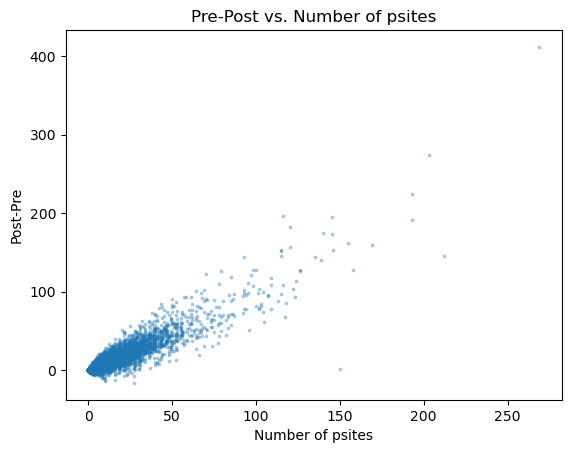

In [5]:
plt.scatter(s3_a_df["idr_psites"], -s3_a_df["pre-post"], s=3, alpha=0.3)
plt.xlabel("Number of psites")
plt.ylabel("Post-Pre")
plt.title("Pre-Post vs. Number of psites")
plt.show()

## 4. Base functions

We define the functions the later sections call:

- `nll(a, s, df)`: the negative log-likelihood of the data for a candidate pair ($\mu$ = `a`, $s$). For each IDR the model says $\Delta\varepsilon \sim \mathcal{N}(n\mu,\ n s^2)$, so the code uses mean `a*xi` and standard deviation `s*sqrt(xi)` and adds up minus the log of the normal density. The log density is written out as $\tfrac{1}{2}\left(\tfrac{y - n\mu}{\sigma}\right)^2 + \ln(\sigma\sqrt{2\pi})$ instead of taking `math.log` of the density: for IDRs far from the line the density is smaller than a float can hold, and `math.log(0)` would crash (the underflow from Session 05).
- `gauss_diff(d, sigma)`: the normal density with mean 0, used for drawing bell curves.
- `linear(x, a)` and `show_fitted_line(...)`: the model's mean, $n\mu$, and a plot of the data with the fitted line and the binned average of the data on top.
- `lcg` and `uniforms`: the linear congruential generator from Session 04. It turns a seed into a reproducible list of numbers on $[0, 1)$, so the same seed always gives the same simulation.
- `draw_from_normal(mu, s, seed)`: one normal draw from 12 uniforms. A uniform has mean $\tfrac12$ and variance $\tfrac{1}{12}$, so the sum of 12 of them minus 6 have mean 0 and variance 1, and a sum of many small independent pieces is close to normal. Multiplying by `s` and adding `mu` gives a draw with mean $\mu$ and standard deviation $s$.



In [6]:
def nll(a, s, df):
    total = 0

    for i in range(len(df)):
        xi = df["idr_psites"][i]
        yi = -df["pre-post"][i]
        if xi == 0:
            continue
        sigma = s * math.sqrt(xi)
        total += ((yi - a * xi) / sigma) ** 2 * 0.5 + math.log(
            sigma * math.sqrt(2 * math.pi)
        )
    return total


def gauss_diff(d, sigma):
    return 1 / (sigma * (2 * math.pi) ** (1 / 2)) * math.exp(d**2 / (-2 * sigma**2))


def linear(x, a):
    return x * a


def show_fitted_line(a, df=s3_a_df, func=linear):
    min_sites = df["idr_psites"].min()
    max_sites = df["idr_psites"].max()

    x_line = np.linspace(min_sites, max_sites, 300)
    y_line = func(x_line, a)
    plt.figure(figsize=(10, 6))
    plt.scatter(
        df["idr_psites"],
        -df["pre-post"],
        s=3,
        alpha=0.3,
    )

    num_bins = 50

    bins = np.linspace(min_sites, max_sites, num_bins + 1)
    df_copy = df.copy()
    df_copy["sites_bin"] = pd.cut(df_copy["idr_psites"], bins=bins, include_lowest=True)

    grouped = df_copy.groupby("sites_bin")["pre-post"].mean().reset_index()
    bin_midpoints = [
        (interval.left + interval.right) / 2 for interval in grouped["sites_bin"]
    ]
    plt.plot(
        bin_midpoints,
        -grouped["pre-post"],
        color="blue",
        linewidth=2,
        label="Mean of -pre-post in bins",
    )

    plt.plot(x_line, y_line, color="red", linewidth=2, label="Fitted model")

    plt.xlim(0.0, 150)
    plt.ylim(0.0, 150)
    plt.xlabel("Number of psites")
    plt.ylabel("Post-Pre")
    plt.title(" Pre-Post vs. Number of psites with average and fitted curve")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (state * a + c) % m


A = 1664525
C = 1013904223
M = 2**32


def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A, C, M)
        out[i] = state / M
    return out


def draw_from_normal(mu, s, us):
    return (sum(us) - 6) * s + mu


## 5. Forward simulation

Given the model's relative simplicity we can actually calculate the closed form solutions for our parameters $\hat\mu$ and $\hat s$ using the following formulas:

$$\hat\mu = \frac{\sum_{i=1}^N\Delta\varepsilon}{\sum_{i=1}^N{n}}$$


$$\hat{s} = \sqrt{\frac{1}{N-1} \sum_{i=1}^N (\varepsilon_i - n\hat{\mu})^2}$$

In [7]:
# Closed-form solution, for n > 0
df_fit = s3_a_df[s3_a_df["idr_psites"] > 0]

n = df_fit["idr_psites"].to_numpy(dtype=float)
y = (-df_fit["pre-post"]).to_numpy(dtype=float)

# mu: sum(y_i) / sum(n_i)
mu_hat = y.sum() / n.sum()

# s^2: average of (y_i - n_i * mu_hat)^2 / n_i
s2_hat = np.mean((y - n * mu_hat) ** 2 / n)
s_hat = np.sqrt(s2_hat)

print(f"mu_hat = {mu_hat:.6f}")
print(f"s_hat  = {s_hat:.6f}")

mu_hat = 0.927535
s_hat  = 1.338997


We generate a simulaed version of Table S3A. Each IDR keeps its real number of sites $n$, and for each site the code draws one random per-site effect from $\mathcal{N}(\mu, s^2)$ with `draw_from_normal`, using $\mu = 0.927$ and $s = 1.338$ . The effects of all sites are added up into one simulated $\Delta\varepsilon$ per IDR.

In [8]:
mu = mu_hat
s = s_hat
seed = 2026
y_sim_1 = []
n_psites = s3_a_df["idr_psites"].to_list()


rs = uniforms(12 * sum(n_psites), seed)
y_sim_1, start = [], 0
for n in n_psites:
    total = 0
    for k in range(n):
        total += draw_from_normal(mu, s, rs[start : start + 12])
        start += 12
    y_sim_1.append(total)


**How to interpret the plots**  
If the mechanism correctly models the data, the simulated points should rise in a straight line from the origin with slope close to $\mu = \hat\mu = 0.927$, and fan out as $n$ grows, similar to the real data below it.

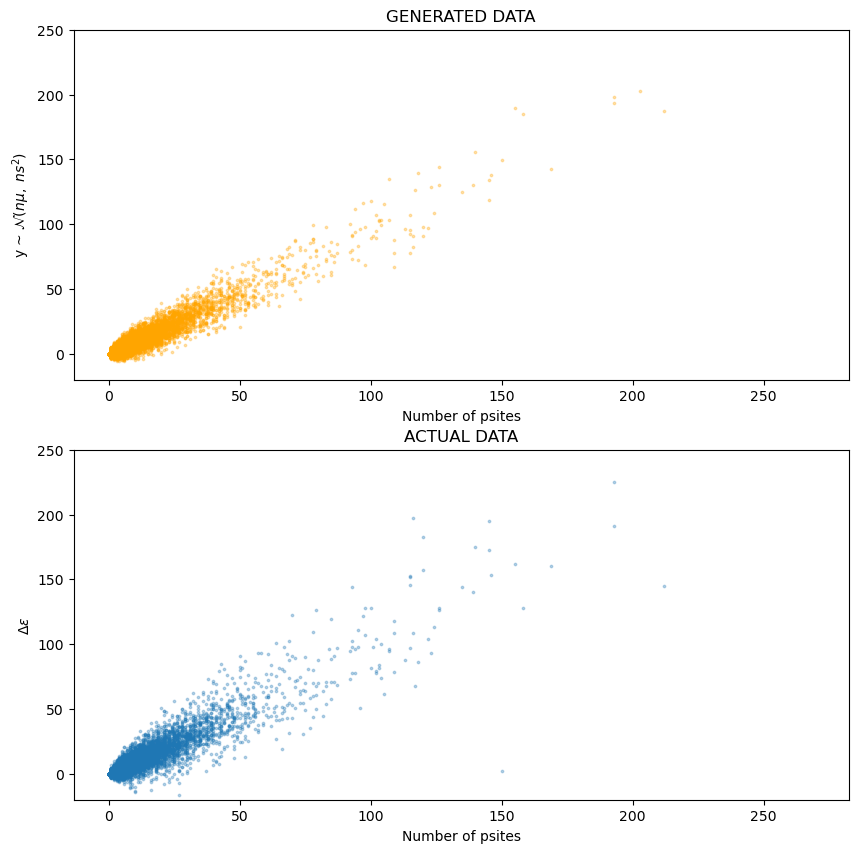

In [9]:
fig, ((ax1, ax2)) = plt.subplots(2, 1, figsize=(10, 10))


ax1.scatter(s3_a_df["idr_psites"], y_sim_1, s=3, alpha=0.3, color="orange")
ax1.set_ylim(-20,250)
ax1.set_title("GENERATED DATA")
ax1.set_ylabel(r"y ~ $\mathcal{N}(n\mu,\ n s^2)$")
ax1.set_xlabel("Number of psites")

ax2.scatter(s3_a_df["idr_psites"], -s3_a_df["pre-post"], s=3, alpha=0.3)
ax2.set_ylim(-20,250)
ax2.set_title("ACTUAL DATA")
ax2.set_ylabel("$\\Delta\\epsilon$")
ax2.set_xlabel("Number of psites")

plt.show()


## 6. Running the model backwards: fitting $\mu$ and $s$

We find the pair ($\hat\mu$, $\hat s$) with the smallest negative log-likelihood by gradient descent.

Each cycle:

1. computes the slope of the NLL with respect to both parameters, written out by hand:
   - $\partial\,\text{NLL}/\partial\mu = \sum_i n_i(n_i\mu - y_i)/(n_i s^2) = \sum_i (n_i\mu - y_i)/s^2$
   - $\partial\,\text{NLL}/\partial s = N/s - \sum_i (n_i\mu - y_i)^2/(s^3 n_i)$
2. proposes a step downhill, $\theta_\text{new} = \theta - \alpha \cdot \text{slope}$;
3. accepts the step only if the NLL drops, and then makes the next step 20% bigger; otherwise it rejects the step and halves $\alpha$. This adaptive step size (Session 06) avoids both a crawl and an overshoot without depending solely on the initial $\alpha$ chosen by hand.

It stops when both slopes are close to zero, which is where the minimum is.

<br>

**Why gradient descent?**  

A grid search over two parameters would also work here, but the candidate values scale with more parameters, so as we saw in the course this was the method used multi-parameter fits.

In [10]:
def fit(alpha=0.001, df=s3_a_df, tolerance=0.001):
    CYCLES = 100
    N = (df["idr_psites"] > 0).sum()

    a, s = 1, 1

    for c in range(CYCLES):
        if c % 1 == 0:
            print(f"Cycle {c}")
        a_der = 0
        s_der = N / s
        current_nll = nll(a, s, df)
        for i in range(len(df)):
            yi = -df["pre-post"][i]
            xi = df["idr_psites"][i]
            if xi == 0:
                continue
            mui = a * xi

            a_der += (mui - yi) / s**2
            s_der -= (mui - yi) ** 2 / (s**3 * xi)
        if abs(a_der) < tolerance and abs(s_der) < tolerance:
            break
        a_new = a - alpha * a_der
        s_new = s - alpha * s_der
        new_nll = nll(a_new, s_new, df)
        if new_nll < current_nll:
            a, s = a_new, s_new
            alpha = alpha * 1.2
            current_nll = new_nll
        else:
            alpha = alpha * 0.5
    return a, s


In [11]:
a, sigma = fit()

Cycle 0
Cycle 1
Cycle 2
Cycle 3
Cycle 4
Cycle 5
Cycle 6
Cycle 7
Cycle 8
Cycle 9
Cycle 10
Cycle 11
Cycle 12
Cycle 13
Cycle 14
Cycle 15
Cycle 16
Cycle 17
Cycle 18
Cycle 19
Cycle 20
Cycle 21
Cycle 22
Cycle 23
Cycle 24
Cycle 25
Cycle 26
Cycle 27
Cycle 28
Cycle 29
Cycle 30
Cycle 31
Cycle 32
Cycle 33
Cycle 34
Cycle 35
Cycle 36
Cycle 37
Cycle 38
Cycle 39
Cycle 40
Cycle 41


mu_hat: 0.9275352309601663, s_hat: 1.3389967323485206


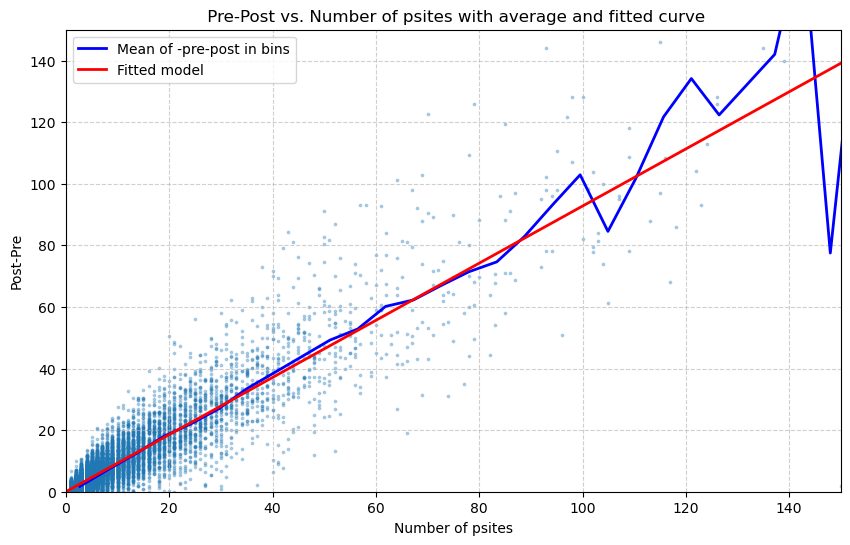

In [12]:
print(f"mu_hat: {a}, s_hat: {sigma}")
show_fitted_line(a)

## 7. Validation: Do the predictions hold for every number of sites?

For IDRs with exactly $n$ sites, we compare the observed mean and variance of $\Delta\varepsilon$ with what the fitted model predicts: mean $n\hat\mu$ and variance $n\hat s^2$.

The fit used all IDRs at once. If the mechanism is right, its two predictions should hold separately for each $n$, and any $n$ where they fail shows where the model is inaccurate.

<br>

**Results:**  

The means follow $n\hat\mu$ closely. The variances do not: the model's spread is too wide for IDRs with 1 to 3 sites and too narrow for IDRs with many.

In [13]:
print("n\tmean:\tdata\tmodel\tvariance:\tdata\tmodel")
for k in [1, 2, 3, 5, 8, 12, 20, 40, 50]:
    group = -s3_a_df[s3_a_df["idr_psites"] == k]["pre-post"]
    mu_cf = k * a
    s_cf = k**0.5 * sigma
    mean = sum(group) / len(group)
    std = np.array(group).std()
    print(f"{k:3d}\t\t{mean:6.2f}\t{mu_cf:6.2f}\t\t\t{std**2:7.2f}\t{s_cf**2:7.2f}")

n	mean:	data	model	variance:	data	model
  1		  0.76	  0.93			   0.85	   1.79
  2		  1.68	  1.86			   2.33	   3.59
  3		  2.61	  2.78			   4.46	   5.38
  5		  4.69	  4.64			  10.25	   8.96
  8		  7.33	  7.42			  18.63	  14.34
 12		 10.85	 11.13			  29.82	  21.51
 20		 18.41	 18.55			  50.95	  35.86
 40		 39.47	 37.10			 248.52	  71.72
 50		 56.02	 46.38			 425.63	  89.65


## 8. Bootstrapping

We build a new dataset by drawing IDRs from the real ones at random with replacement, and for each draw we refit the model and repeat. The spread of the refitted values is the uncertainty on $\hat\mu$ and $\hat s$ (Session 08).

This way we can estimate the distriubtion of the parameters as well as their spread and 95% confidence interval

**Optimized functions**
`nll_optimized` and `fit_optimized` compute the same quantities as `nll` and `fit` in section 4, but on whole `numpy` arrays at once instead of one IDR at a time. This increases efficiency greatly which is needed to fit multiple draws within a reasonable amount of time

The plots show both distributions, with the mean and $\pm 1.96$ standard deviations, which covers 95% of a normal distribution.

In [14]:
# Vectorize for faster versions of nll() and fit()
def nll_optimized(a, s, df):
    total = 0
    df_nonzero = df[df["idr_psites"] > 0]
    x = df_nonzero["idr_psites"].to_numpy()
    y = -df_nonzero["pre-post"].to_numpy()
    sigma = s * x**0.5

    total = (
        ((y - a * x) / sigma) ** 2 * 0.5 + np.log(sigma * math.sqrt(2 * math.pi))
    ).sum()

    return total


def fit_optimized(alpha=0.001, df=s3_a_df, tolerance=0.001):
    CYCLES = 1000
    df_nonzero = df[df["idr_psites"] > 0]
    N = len(df_nonzero)

    a, s = 1, 1

    for c in range(CYCLES):
        current_nll = nll_optimized(a, s, df_nonzero)

        y = -df_nonzero["pre-post"].to_numpy()
        x = df_nonzero["idr_psites"].to_numpy()

        mu = a * x
        a_der = ((mu - y) / s**2).sum()
        s_der = N / s - ((mu - y) ** 2 / (s**3 * x)).sum()

        if abs(a_der) < tolerance and abs(s_der) < tolerance:
            break
        a_new = a - alpha * a_der
        s_new = s - alpha * s_der
        new_nll = nll_optimized(a_new, s_new, df_nonzero)
        if new_nll < current_nll:
            a, s = a_new, s_new
            alpha = alpha * 1.2
            current_nll = new_nll
        else:
            alpha = alpha * 0.5
    return a, s

In [15]:
# Fit draws with replacement to obtain parameter distributions
fitted_as = []
fitted_sigmas = []
num_bootstraps = 10000

for _ in range(num_bootstraps):
    boostrap_df = s3_a_df.sample(frac=1, replace=True).reset_index(drop=True)
    a_boot, sigma_boot = fit_optimized(df=boostrap_df)
    fitted_as.append(a_boot)
    fitted_sigmas.append(sigma_boot)

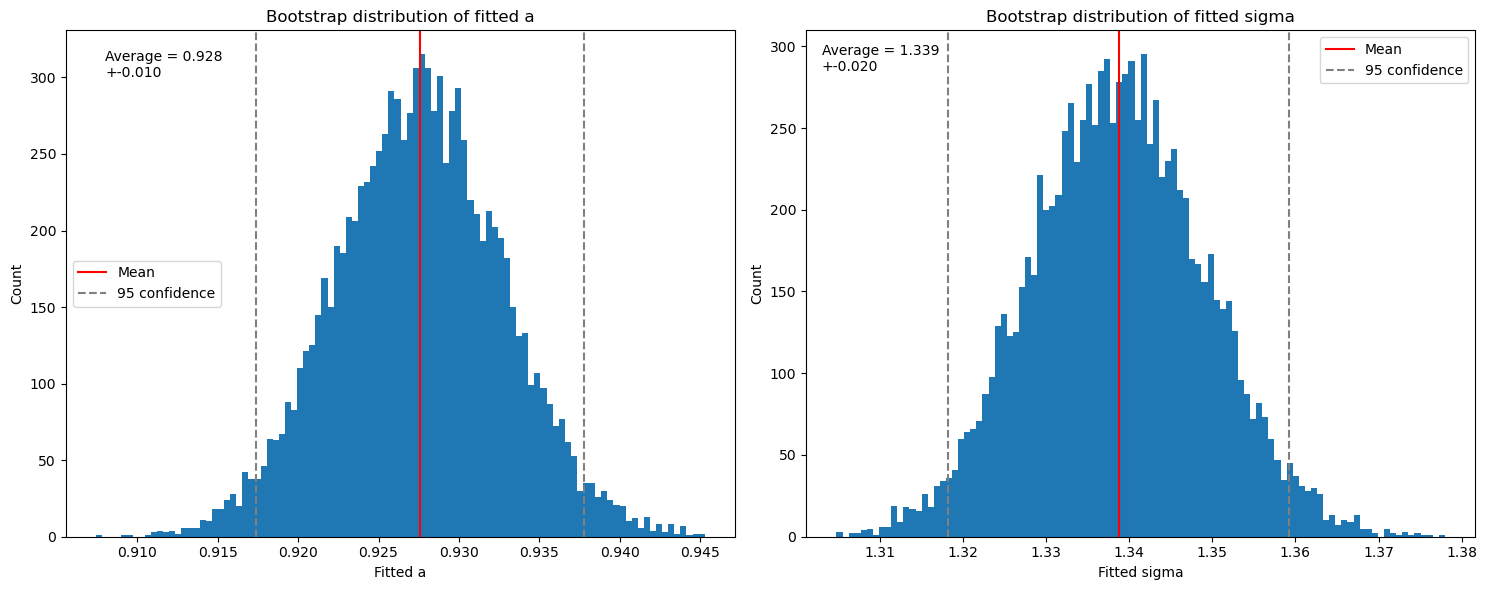

In [21]:
# Get means and 95% confidence intervals
mean_a = np.mean(fitted_as)
mean_sigma = np.mean(fitted_sigmas)

a_95 = np.std(fitted_as) * 1.96
sigma_95 = np.std(fitted_sigmas) * 1.96

# Plot histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(fitted_as, bins=100)
ax1.axvline(mean_a, color="red", label="Mean")
ax1.axvline(mean_a + a_95, linestyle="dashed", color="grey", label="95 confidence")
ax1.axvline(mean_a - a_95, linestyle="dashed", color="grey")
ax1.text(s=f"Average = {mean_a:.3f}\n+-{a_95:.3f}", x=0.908, y=300)
ax1.set_title("Bootstrap distribution of fitted a")
ax1.set_xlabel("Fitted a")
ax1.set_ylabel("Count")
ax1.legend()

ax2.hist(fitted_sigmas, bins=100)
ax2.axvline(mean_sigma, color="red", label="Mean")
ax2.axvline(
    mean_sigma + sigma_95, linestyle="dashed", color="grey", label="95 confidence"
)
ax2.axvline(mean_sigma - sigma_95, linestyle="dashed", color="grey")
ax2.text(s=f"Average = {mean_sigma:.3f}\n+-{sigma_95:.3f}", x=1.303, y=285)
ax2.set_title("Bootstrap distribution of fitted sigma")
ax2.set_xlabel("Fitted sigma")
ax2.set_ylabel("Count")
ax2.legend()

plt.tight_layout()
plt.show()

From this we see that $\hat\mu$ is found between $\pm 0.01$ and $\hat s$ to between $\pm 0.02$ (95% range of the refits). 

## 9. Breaking the model

The model makes one claim we can test for every number of sites: an IDR's deviation from the fitted line $n_i\hat\mu$, divided by the model's spread $\sqrt{n}\,\hat s$, should behave like a draw from a standard normal, so its standard deviation should be 1 regardless of the value of $n$:

$$z_i = \frac{\Delta\varepsilon_i - n_i\hat\mu}{\sqrt{n_i}\,\hat s}$$


We calculate $z$ for every IDR, and plot the standard deviation of $z$ for each number of sites.

mu_hat = 0.9275    s_hat = 1.3390
IDRs more than 3 model standard deviations from the line: 1.14 %   (model: 0.27 %)


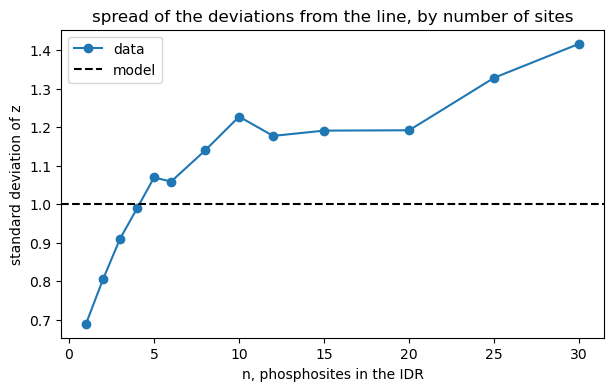

In [17]:
data_a = s3_a_df[s3_a_df["idr_psites"] > 0]
n_a = data_a["idr_psites"].to_numpy()
d_a = -data_a["pre-post"].to_numpy()

z = (d_a - n_a * a) / (np.sqrt(n_a) * sigma)
ks = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30]
sd_z = [np.std(z[n_a == k]) for k in ks]

print(f"mu_hat = {a:.4f}    s_hat = {sigma:.4f}")
print(
    f"IDRs more than 3 model standard deviations from the line: {100 * np.mean(np.abs(z) > 3):.2f} %   (model: 0.27 %)"
)

plt.figure(figsize=(7, 4))
plt.plot(ks, sd_z, marker="o", label="data")
plt.axhline(1, color="black", linestyle="--", label="model")
plt.xlabel("n, phosphosites in the IDR")
plt.ylabel("standard deviation of z")
plt.title("spread of the deviations from the line, by number of sites")
plt.legend()
plt.show()

**What this tells us:**  
The spread is too small for IDRs with one or two sites and too large for IDRs with many, and about four times as many IDRs lie beyond $\pm 3$ as the model allows. A single per-site spread $s$ cannot be right for all IDRs.

### Main limitations

1. **Sites are not independent and not identical.**  
The effects of the sites in one IDR pile up in the same direction more than independent draws would (the plot above). One reason is a site's neighbourhood: when we counted the charged residues within 5 positions of each site, IDRs whose sites sit among acidic residues (D, E) lay above the line and those among basic residues (K, R) below it (correlations of +0.34 and −0.26 with $z$). An added E next to positive charges partly pairs with them, so it adds less repulsion. The model ignores this (assumption 3).
2. **Error bars are too optimistic for heavily phosphorylated IDRs.**  
For the paper's example protein ZO-1, the model's 95% range contains the FINCHES value for its IDRs with 2 and 15 sites, but for the C-terminal IDR with 120 sites it predicts 111 where FINCHES gives 183. The direction is right; the size is underestimated.
3. **Scope.**  
The model describes FINCHES predictions with every known site replaced by E at once. Real phosphorylation modifies only some sites at a time, and a phosphate carries more negative charge than E, so the model says nothing direct about measured interactions of phosphorylated proteins.

